
# 🧠 Day 23: Support Vector Machines (SVM) — **Premium Deep Dive (Final Version)**

---

## 🎯 Learning Objective
Build a **deep, intuitive + mathematical understanding** of SVM, with strong real-world connections (especially BFSI).

---



-Support Vector Machine (SVM) is a supervised machine learning algorithm used for classification and regression.

-Its main goal is to find the best boundary (called a hyperplane) that separates different classes.

-SVM chooses the boundary that has the maximum distance (margin) from the nearest data points.

-The closest data points to the boundary are called support vectors.

-These support vectors are the most important points in defining the decision boundary.

-SVM works well for both simple (linear) and complex (non-linear) data.

-For non-linear data, SVM uses something called the kernel trick to transform data into higher dimensions.

-Common kernels include linear, polynomial, and RBF (Radial Basis Function).

-SVM is powerful but can be slow for very large datasets.

-It is widely used in real-world problems like fraud detection, spam filtering, and image classification.




---

# 🔷 Hyperplane

### 📘 1. Explanation

A hyperplane is the central idea behind SVM. It represents the decision boundary that separates classes.

Think of it like a line dividing fraud and non-fraud transactions. But unlike simple models, SVM does not just pick any line — it carefully selects the **optimal boundary** that creates maximum separation.

In higher dimensions, this becomes more powerful as it can separate complex feature spaces.

---

### 📐 2. Formula

**w^T x + b = 0**

👉 This formula tells us how the model mathematically represents the concept.

---

### 🏦 3. Real Life Use Case

In fraud detection, a hyperplane separates genuine vs suspicious transactions using features like transaction amount, time, and location.

---

### ⚠️ 4. Limitation

Fails when data is not linearly separable unless kernel trick is used.

---

### ⚖️ 5. Comparison

Logistic Regression focuses on probability, while SVM focuses on strongest separation.

---

### 💻 6. Hands-on Example



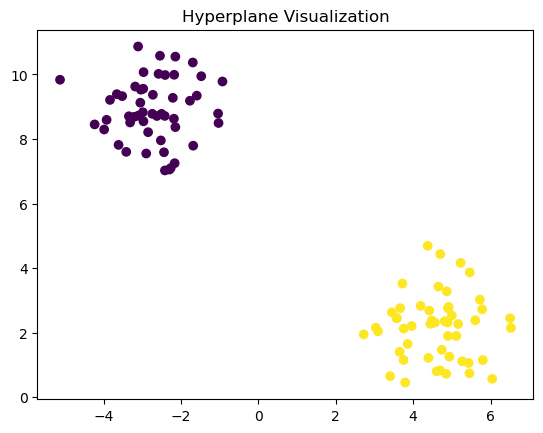

In [1]:
from sklearn.svm import SVC
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=100, centers=2, random_state=42)

model = SVC(kernel='linear')
model.fit(X, y)

plt.scatter(X[:,0], X[:,1], c=y)
plt.title("Hyperplane Visualization")
plt.show()


---

# 🔷 Margin (Maximum Margin Concept)

### 📘 1. Explanation

Margin is the distance between the hyperplane and the closest data points.

SVM maximizes this margin to ensure that the model is robust and less sensitive to noise. A larger margin means better generalization to unseen data.

This is what makes SVM fundamentally different from many other models.

---

### 📐 2. Formula

**Margin = 2 / ||w||**

👉 This formula tells us how the model mathematically represents the concept.

---

### 🏦 3. Real Life Use Case

In credit risk modeling, a larger margin ensures that borderline customers are classified more safely.

---

### ⚠️ 4. Limitation

Sensitive to extreme outliers that can distort margin.

---

### ⚖️ 5. Comparison

KNN does not consider margin; Logistic Regression does not explicitly maximize margin.

---

### 💻 6. Hands-on Example



In [6]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)
model = SVC(kernel='linear')
model.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


Hard Margin SVM
- In a hard margin SVM, the objective is to identify a hyperplane that completely separates data points belonging to different classes, ensuring a clear demarcation with the utmost margin width possible. This margin is the distance between the hyperplane and the nearest data point, also known as the support vectors.

- Advantages of Hard Margin
- Guaranteed Separation: Hard margin SVM ensures that the classes are perfectly separated, leading to optimal generalization performance when the training data is linearly separable.
- Simplicity: The optimization problem in hard margin SVM is well-defined and has a unique solution, making it computationally efficient.

  
- Disadvantages of Hard Margin
- Sensitivity to Outliers: Hard margin SVM is highly sensitive to outliers or noisy data points. Even a single mislabeled point can significantly affect the position of the decision boundary and lead to poor generalization on unseen data.
- Not Suitable for Non-linear Data: When the data is not linearly separable, hard margin SVM fails to find a valid solution, rendering it impractical for many real-world datasets.

Soft Margin SVM
Soft Margin SVM introduces flexibility by allowing some margin violations (misclassifications) to handle cases where the data is not perfectly separable. Suitable for scenarios where the data may contain noise or outliers. It Introduces a penalty term for misclassifications, allowing for a trade-off between a wider margin and a few misclassifications.

- Soft Margin SVM
- Soft Margin SVM introduces flexibility by allowing some margin violations (misclassifications) to handle cases where the data is not perfectly separable. Suitable for scenarios where the data may contain noise or outliers. It Introduces a penalty term for misclassifications, allowing for a trade-off between a wider margin and a few misclassifications.

- Advantages of Soft Margin SVM
- Robustness to Outliers: Soft margin SVM can handle outliers or noisy data more effectively by allowing for some misclassifications. This results in a more robust decision boundary that generalizes better to unseen data.
- Applicability to Non-linear Data: Unlike hard margin SVM, soft margin SVM can handle non-linearly separable data by implicitly mapping it to a higher-dimensional space using kernel functions. This enables SVM to capture complex decision boundaries.
- Disadvantages of Soft Margin SVM
- Need for Parameter Tuning: The performance of soft margin SVM heavily depends on the choice of the regularization parameter C. Selecting an appropriate value for C requires careful tuning, which can be time-consuming and computationally expensive, especially for large datasets.
- Potential Overfitting: In cases where the value of C is too large, soft margin SVM may overfit the training data by allowing too many margin violations.

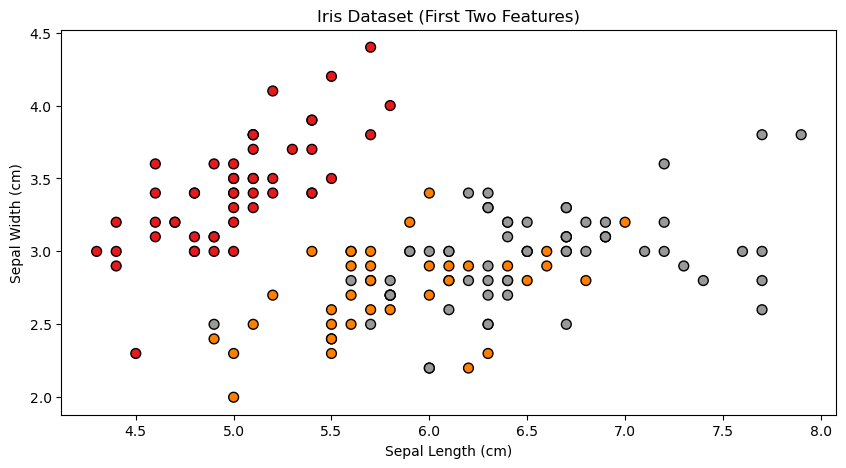

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.svm import SVC

iris = load_iris()
X = iris.data[:, :2]  # We'll use only the first two features for visualization
y = iris.target

plt.figure(figsize=(10, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, s=50, edgecolors='k')
plt.title('Iris Dataset (First Two Features)')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.show()

In [3]:
hard_margin_svm = SVC(kernel='linear', C=float(10**10))
hard_margin_svm.fit(X, y)

soft_margin_svm = SVC(kernel='linear', C=1.0)
soft_margin_svm.fit(X, y)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


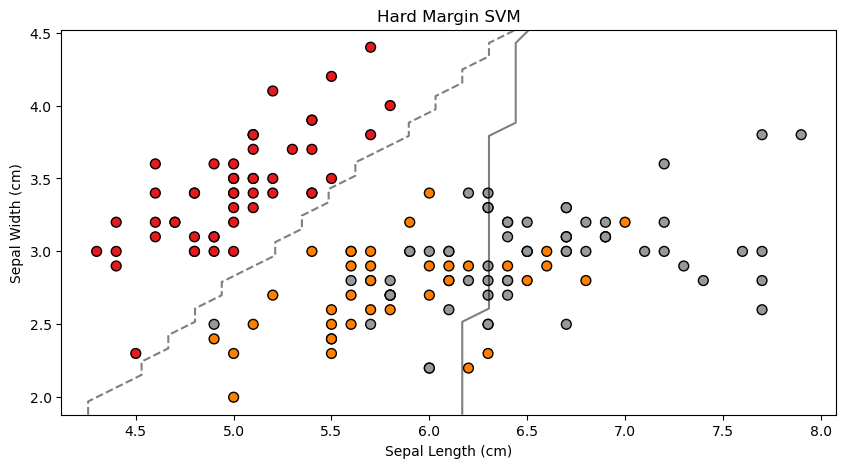

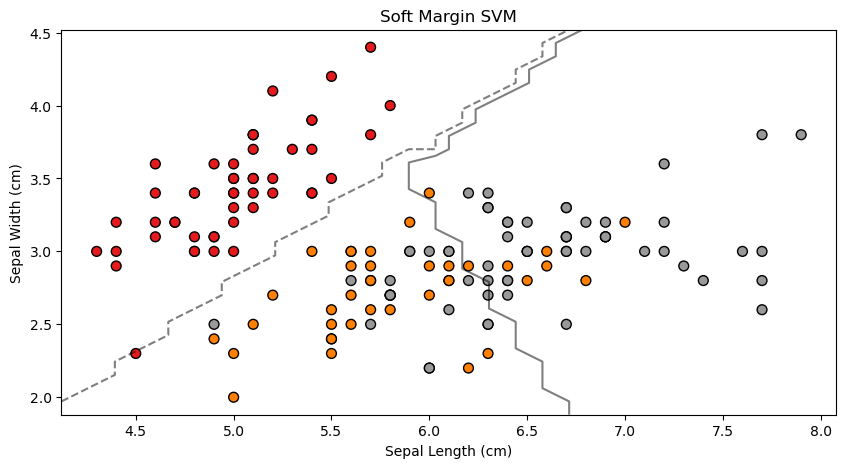

In [4]:
# Plot decision boundaries
def plot_decision_boundary(model, title):
    plt.figure(figsize=(10, 5))
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Set1, s=50, edgecolors='k')
    
    ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # Create grid to evaluate model
    xx = np.linspace(xlim[0], xlim[1], 30)
    yy = np.linspace(ylim[0], ylim[1], 30)
    YY, XX = np.meshgrid(yy, xx)
    xy = np.vstack([XX.ravel(), YY.ravel()]).T
    Z = model.predict(xy).reshape(XX.shape)
    
    # Plot decision boundary and margins
    ax.contour(XX, YY, Z, colors='k', levels=[0, 1, 2], alpha=0.5, linestyles=['--', '-', '--'])
    plt.title(title)
    plt.xlabel('Sepal Length (cm)')
    plt.ylabel('Sepal Width (cm)')
    plt.show()

# Plot decision boundaries for both SVMs
plot_decision_boundary(hard_margin_svm, 'Hard Margin SVM')
plot_decision_boundary(soft_margin_svm, 'Soft Margin SVM')


---

# 🔷 Support Vectors

### 📘 1. Explanation

Support vectors are the most critical data points in SVM.

These are the points closest to the hyperplane, and they directly influence the position of the boundary. If these points move, the boundary moves.

This makes SVM efficient because it does not depend on all data points — only key ones.

---

### 📐 2. Formula

**y(w^Tx + b) = 1**

👉 This formula tells us how the model mathematically represents the concept.

---

### 🏦 3. Real Life Use Case

Transactions near the fraud boundary are treated as high-risk and monitored carefully.

---

### ⚠️ 4. Limitation

Highly sensitive to noisy or mislabelled data.

---

### ⚖️ 5. Comparison

Unlike Logistic Regression, which uses all points, SVM relies heavily on a few points.

---

### 💻 6. Hands-on Example



In [8]:
model = SVC(kernel='linear')
model.fit(X_train, y_train)

print(model.support_vectors_[:20])

[[4.9 3.1]
 [5.4 3.4]
 [4.9 3. ]
 [4.9 3.1]
 [5.5 3.5]
 [5.4 3.4]
 [4.8 3. ]
 [5.8 4. ]
 [4.8 3. ]
 [5.8 2.7]
 [6.8 2.8]
 [6.3 2.3]
 [6.  2.9]
 [6.  2.7]
 [5.7 2.9]
 [6.7 3. ]
 [6.1 2.8]
 [6.  3.4]
 [5.7 2.8]
 [6.1 2.8]]



---

# 🔷 Hinge Loss

### 📘 1. Explanation

Hinge loss is the loss function used in SVM.

It penalizes not just incorrect predictions but also correct predictions that are too close to the boundary.

This ensures that the model not only classifies correctly but does so confidently.

---

### 📐 2. Formula

**max(0, 1 - y(w^Tx + b))**

👉 This formula tells us how the model mathematically represents the concept.

---

### 🏦 3. Real Life Use Case

In spam detection, borderline emails are penalized to improve classification confidence.

---

### ⚠️ 4. Limitation

Does not produce probability outputs like log loss.

---

### ⚖️ 5. Comparison

Logistic regression uses log loss, which gives probabilities; SVM uses hinge loss for margin optimization.

---

### 💻 6. Hands-on Example



In [9]:
import numpy as np

y = np.array([1, -1])
pred = np.array([0.5, -0.2])

loss = np.maximum(0, 1 - y * pred)
print(loss)

[0.5 0.8]



---

# 🔷 Kernel Trick

### 📘 1. Explanation

The kernel trick allows SVM to solve non-linear problems.

Instead of explicitly transforming data into higher dimensions, it computes relationships in that space indirectly.

This makes it computationally efficient while still capturing complex patterns.

---

### 📐 2. Formula

**K(x, x') = φ(x)·φ(x')**

👉 This formula tells us how the model mathematically represents the concept.

---

### 🏦 3. Real Life Use Case

Used in image recognition and complex fraud pattern detection.

---

### ⚠️ 4. Limitation

Choosing wrong kernel can degrade performance significantly.

---

### ⚖️ 5. Comparison

Linear vs RBF kernel trade-off between simplicity and flexibility.

---

### 💻 6. Hands-on Example



In [10]:
model = SVC(kernel='rbf')
model.fit(X_train, y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False



---

# 🔷 Hyperparameters (C, gamma, degree)

### 📘 1. Explanation

Hyperparameters control the behavior of SVM.

- C controls trade-off between margin and classification error
- gamma controls influence of individual data points
- degree applies to polynomial kernel

These parameters directly impact model complexity and performance.

---

### 📐 2. Formula

**C, gamma, degree**

👉 This formula tells us how the model mathematically represents the concept.

---

### 🏦 3. Real Life Use Case

In banking, tuning C determines how strict fraud detection should be.

---

### ⚠️ 4. Limitation

Requires careful tuning; wrong values lead to overfitting or underfitting.

---

### ⚖️ 5. Comparison

High gamma → overfit, low gamma → underfit.

---

### 💻 6. Hands-on Example



In [11]:
model = SVC(C=1, gamma=0.1)
model.fit(X_train, y_train)

,C,1
,kernel,'rbf'
,degree,3
,gamma,0.1
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False



---

# 🔷 SVM for Regression (SVR)

### 📘 1. Explanation

SVM can also be used for regression tasks.

Instead of predicting exact values, it tries to fit within a margin of tolerance (epsilon).

This makes it robust to noise.

---

### 📐 2. Formula

**|y - f(x)| < ε**

👉 This formula tells us how the model mathematically represents the concept.

---

### 🏦 3. Real Life Use Case

Used in stock price prediction with tolerance bands.

---

### ⚠️ 4. Limitation

Sensitive to epsilon selection.

---

### ⚖️ 5. Comparison

Different from linear regression which minimizes squared error.

---

### 💻 6. Hands-on Example



In [12]:
from sklearn.svm import SVR

model = SVR()
model.fit(X_train, y_train)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1



---

# 🔷 SVM vs KNN

### 📘 1. Explanation

SVM and KNN are fundamentally different.

SVM learns a decision boundary, while KNN memorizes data and makes predictions based on neighbors.

SVM is better for high-dimensional structured data, while KNN works well for local patterns.

---

### 📐 2. Formula

**N/A**

👉 This formula tells us how the model mathematically represents the concept.

---

### 🏦 3. Real Life Use Case

KNN used in recommendation systems; SVM used in fraud detection.

---

### ⚠️ 4. Limitation

KNN is slow during prediction; SVM is slow during training.

---

### ⚖️ 5. Comparison

Boundary-based vs instance-based learning.

---

### 💻 6. Hands-on Example



In [13]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None



---

# 🔷 Computational Complexity

### 📘 1. Explanation

SVM is computationally expensive.

Training time grows rapidly with dataset size, making it less suitable for very large datasets.

However, it performs very well on medium-sized datasets with clear margins.

---

### 📐 2. Formula

**O(N^2 to N^3)**

👉 This formula tells us how the model mathematically represents the concept.

---

### 🏦 3. Real Life Use Case

Used in fraud detection systems where dataset size is manageable but accuracy is critical.

---

### ⚠️ 4. Limitation

Not scalable for massive datasets.

---

### ⚖️ 5. Comparison

Tree-based models scale better.

---

### 💻 6. Hands-on Example



In [ ]:
# No code required